# **Ejercicio Opcional APIs**

Trabajar con Excels y CSVs descargados está bien para empezar, pero en el mundo real los datos cambian constantemente. Las APIs sirven para conectar nuestro código en Python directamente a bases de datos externas y extraer información actualizada.

Cada API tiene sus reglas. Algunas son de pago, otras requieren claves de acceso y todas organizan la información de manera distinta. Por eso, la principal habilidad al usar una API es leer su documentación. Vamos a usar la [PokéAPI](https://pokeapi.co/docs/v2), una base de datos pública y sin registro.

## El Reto: Registro Civil de Kanto

Tu trabajo es generar el Carnet de Identidad de los Pokémon que traen los entrenadores. Para ello no puedes fiarte de la memoria del entrenador, tienes que conectarte a la API, extraer los datos del Pokémon, limpiarlos y guardarlos y generar el documento de identidad.

Tu primer cliente quiere registrar a su Pikachu.

### Paso 1: La URL y la petición (requests.get)

Para pedirle información a la API, necesitamos la dirección exacta. Esta URL se construye uniendo tres partes en este caso:

1. URL Base (https://pokeapi.co/api/v2/): La raíz de la API. Todas las peticiones empiezan aquí.

2. Endpoint (pokemon): La categoría de datos que estamos consultando.

3. Recurso (pikachu): La entrada exacta que queremos buscar dentro de esa categoría.

Puedes revisar la documentación para identificar los endpoint y los recursos. También para comprobar la estructura en la que se guardan los datos, muy importante para luego extraer la verdadera información.

In [5]:
import requests
import pandas as pd

endpoint = "pokemon"
recurso = "pikachu"

url = f"https://pokeapi.co/api/v2/{endpoint}/{recurso}"
datos_pikachu = requests.get(url)

Usamos la función requests.get() para hacer la consulta. Esta función no nos da los datos inmediatamente, sino una respuesta. Puedes probar haciendo un print del tipo. Si el código de estado de esa respuesta es 200, significa que la conexión ha sido un éxito y podemos proceder a leer los datos.

In [6]:
# Comprobamos el código de estado (200 = OK, 404 = No encontrado)
print(type(datos_pikachu), datos_pikachu)

<class 'requests.models.Response'> <Response [200]>


### Paso 2: Desempaquetar los datos (.json())

La variable datos_pokechu de nuestro paso anterior contiene la respuesta del servidor, pero no los datos legibles. Para extraer la información real, usa el método .json() y guárdalo en una variable llamada json_pokechu.

In [7]:
json_pikachu = datos_pikachu.json()
json_pikachu

{'abilities': [{'ability': {'name': 'static',
    'url': 'https://pokeapi.co/api/v2/ability/9/'},
   'is_hidden': False,
   'slot': 1},
  {'ability': {'name': 'lightning-rod',
    'url': 'https://pokeapi.co/api/v2/ability/31/'},
   'is_hidden': True,
   'slot': 3}],
 'base_experience': 112,
 'cries': {'latest': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/25.ogg',
  'legacy': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/legacy/25.ogg'},
 'forms': [{'name': 'pikachu',
   'url': 'https://pokeapi.co/api/v2/pokemon-form/25/'}],
 'game_indices': [{'game_index': 84,
   'version': {'name': 'red', 'url': 'https://pokeapi.co/api/v2/version/1/'}},
  {'game_index': 84,
   'version': {'name': 'blue', 'url': 'https://pokeapi.co/api/v2/version/2/'}},
  {'game_index': 84,
   'version': {'name': 'yellow',
    'url': 'https://pokeapi.co/api/v2/version/3/'}},
  {'game_index': 25,
   'version': {'name': 'gold', 'url': 'https://pokeapi.co/api/v2/version

Como ves, la API nos devuelve una cantidad absurda de información. 

Pero para nuestro Carnet de Identidad Pokémon, sólo necesitamos estos datos clave:

1. ID

2. Nombre

3. Tipo 1 y Tipo 2

4. Las 6 estadísticas base (HP, Ataque, Defensa, Ataque Especial, Defensa Especial, Velocidad)

5. Peso (weight) y Altura (height)

6. La imagen oficial del pokemon.

7. La descripción de su especie.

8. Una de sus habilidades.

### Paso 3: Pasando los datos a Pandas

Nuestra herramienta de trabajo final es un DataFrame. 
Crea un DataFrame desde el json_pokechu, puedes usar el constructor propio de DataFrame o el método json_normalize() de pandas.
Una vez lo hagás, haz un head().

In [8]:
data_poke = pd.DataFrame([json_pikachu])
data_poke.head()

,abilities,base_experience,cries,forms,game_indices,height,held_items,id,is_default,location_area_encounters,...,name,order,past_abilities,past_stats,past_types,species,sprites,stats,types,weight
0,"[{'ability': {'name': 'static', 'url': 'https:...",112,{'latest': 'https://raw.githubusercontent.com/...,"[{'name': 'pikachu', 'url': 'https://pokeapi.c...","[{'game_index': 84, 'version': {'name': 'red',...",4,"[{'item': {'name': 'oran-berry', 'url': 'https...",25,True,https://pokeapi.co/api/v2/pokemon/25/encounters,...,pikachu,35,"[{'abilities': [{'ability': None, 'is_hidden':...","[{'generation': {'name': 'generation-i', 'url'...",[],"{'name': 'pikachu', 'url': 'https://pokeapi.co...",{'back_default': 'https://raw.githubuserconten...,"[{'base_stat': 35, 'effort': 0, 'stat': {'name...","[{'slot': 1, 'type': {'name': 'electric', 'url...",60


El problema de los datos anidados

Si te fijas en la tabla que acabamos de generar, verás algo raro. Hay columnas (como abilities, stats o types) que en lugar de tener un valor simple como "60" o "Electric", tienen listas [...] o más diccionarios {...} metidos en la misma celda.

¿Por qué pasa esto? Porque el JSON original no es plano. Tiene una estructura de árbol: un Pokémon tiene una lista de estadísticas, y cada estadística tiene su propio nombre y valor.

Trabajar con tablas que tienen listas dentro de sus celdas es una dolor para hacer cálculos o gráficos y es lo más normal cuando obtienes la información desde una API.

### Paso 4: Crear una función de limpieza

Como funcionario de Datos en Kanto, no vas a hacer este proceso a mano solo para Pikachu. Tendrás que procesar cientos de solicitudes.

Crea la función procesar_pokemon(json_data). Esta función debe recibir el JSON crudo de cualquier Pokémon y devolver un diccionario limpio con las siguientes claves y condiciones:

1. id, nombre, habilidad, peso y altura.

2. tipo_1 y tipo_2. Si el Pokémon solo tiene un tipo, asígnale el valor None a tipo_2.

3. Una clave por cada una de las 6 estadísticas base (hp, attack, etc.).

4. El enlace de la imagen "front_default" del arte oficial que se encuentra dentro de sprites. Vas a tener que bucear bien dentro del diccionario para encontrarla.

5. La descripción de la especie del pokemon.

Una vez lo tengas pruébalo para crear un DataFrame con todos los valores limpios de Pikachu.

In [34]:
def procesar_pokemon(json_data):
    '''Procesa un JSON enraizado para extraer los datos basicos del pokemon'''
    import random
    
    pokemon = {
    }
    stats = {
    }
    
    pokemon["id"] = json_data['id']
    pokemon["nombre"] = json_data['name']
    pokemon["habilidad"] = json_data['abilities'][0]['ability']['name']
    
    habilidad_url = json_data['abilities'][0]['ability']['url']
    habilidad_res = requests.get(habilidad_url)
    json_hab = habilidad_res.json()
    for entrada in json_hab['effect_entries']:
        if entrada['language']['name'] == 'en':
            pokemon['hab_desc'] = entrada['short_effect'] 
    
    pokemon["peso"] = json_data['weight']
    pokemon["altura"] = json_data['height']
    pokemon["tipo_1"] = json_data['types'][0]['type']['name']
    
    if len(json_data['types']) > 1:
        pokemon["tipo_2"] = json_data['types'][1]['type']['name']
    else:
        pokemon["tipo_2"] = ""
    
    stats = {stat['stat']['name']: stat['base_stat'] for stat in json_data['stats']}
    pokemon['img'] = json_data['sprites']['front_shiny']

    url = f"https://pokeapi.co/api/v2/pokemon-species/{pokemon['id']}/"
    description = requests.get(url)
    json_desc = description.json()
            
    descripciones = [desc['flavor_text'] for desc in json_desc['flavor_text_entries'] 
                        if desc['language']['name'] == 'es']
    if descripciones:
        pokemon['descripcion'] = random.choice(descripciones)
    
    pokemon.update(stats)
    
    return pokemon
      

In [35]:
df_pika = pd.DataFrame([procesar_pokemon(json_pikachu)])
df_pika

,id,nombre,habilidad,hab_desc,peso,altura,tipo_1,tipo_2,img,descripcion,hp,attack,defense,special-attack,special-defense,speed
0,25,pikachu,static,Has a 30% chance of paralyzing attacking Pokém...,60,4,electric,,https://raw.githubusercontent.com/PokeAPI/spri...,Este Pokémon tiene unas bolsas en las mejillas...,35,55,40,50,50,90


### Paso 5 - La descripción de la especie y la habilidad.

Si no te diste cuenta, te lo digo yo. Tanto la biografía de la especie como los detalles de su habilidad no vienen dentro del primer JSON. Lo que nos da la API en su lugar es un enlace (url).

Esto es una práctica estándar en el diseño de APIs. Si el servidor nos mandara toda la biografía en todos los idiomas y el texto de cada habilidad de golpe, la descarga sería enorme y lentísima. Por eficiencia, las APIs te entregan los datos superficiales y te dejan enlaces para que hagas nuevas peticiones solo si realmente necesitas profundizar.

Investiga tu JSON crudo o la documentación de la [PokéAPI](https://pokeapi.co/docs/v2) para encontrar dónde están escondidas esas URLs. Haz las nuevas requests, limpia los datos e introduce el texto de la biografía y de la habilidad en tu diccionario antes de pasarlo al DataFrame.

In [16]:
import random

# pokemon_id = random.randint(0, 150)
url = f"https://pokeapi.co/api/v2/pokemon-species/25/"
description = requests.get(url)
json_desc = description.json()
for desc in json_desc['flavor_text_entries']:
    if desc['language']['name'] == 'es':
        df_pika['descripcion'] = desc['flavor_text']
        
df_pika

,id,nombre,habilidad,hab_desc,peso,altura,tipo_1,tipo_2,img,descripcion,hp,attack,defense,special-attack,special-defense,speed
0,25,pikachu,static,Has a 30% chance of paralyzing attacking Pokém...,60,4,electric,,https://raw.githubusercontent.com/PokeAPI/spri...,Los miembros de esta especie se saludan entre\...,35,55,40,50,50,90


In [33]:
habilidad_url = json_pikachu['abilities'][1]['ability']['url']
habilidad_res = requests.get(habilidad_url)
json_hab = habilidad_res.json()
for entrada in json_hab['effect_entries']:
    if entrada['language']['name'] == 'en':
        df_pika['hab_desc'] = entrada['short_effect']

df_pika 

,id,nombre,habilidad,hab_desc,peso,altura,tipo_1,tipo_2,img,descripcion,hp,attack,defense,special-attack,special-defense,speed
0,25,pikachu,static,Redirects single-target electric moves to this...,60,4,electric,,https://raw.githubusercontent.com/PokeAPI/spri...,Acumulan electricidad de forma natural. Los\nb...,35,55,40,50,50,90


### Paso 6 - A crear el CIP!

Este paso es el más sencillo. Si tienes tu DataFrame con los datos limpios y listos sólo tienes que rellenar los campos de la función de abajo y comprueba como el CIP de Pikachu ya está listo. Ahora el entrenador de Pikachu ya puede llevarlo al centro pokemon para que le atiendan gratis.

In [29]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import requests
from io import BytesIO
import textwrap

def crear_carnet(nombre, pokedex_id, tipo_1, tipo_2, altura, peso, imagen, lista_stats, habilidad_nombre, habilidad_efecto, descripcion):
    """
    Genera un Carné de Identidad usando Matplotlib. Devuelve el objeto Figure.
    Agrupa absolutamente todo el texto en la columna central y elimina la fila inferior.
    """   
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"CARNET DE IDENTIDAD POKEMON: {nombre.upper()}", fontsize=18, fontweight='bold', y=0.95)
        
    grid = fig.add_gridspec(1, 3, width_ratios=[1, 1.3, 1.2])
   
    ax_img = fig.add_subplot(grid[0, 0])
    ax_img.axis('off')
    try:
        respuesta = requests.get(imagen)
        img = mpimg.imread(BytesIO(respuesta.content))
        ax_img.imshow(img)
    except:
        ax_img.text(0.5, 0.5, "Imagen no disponible", ha='center', va='center')
    
    ax_info = fig.add_subplot(grid[0, 1])
    ax_info.axis('off') 
    
    texto_tipo2 = tipo_2.capitalize() if tipo_2 else "-"
        
    ancho_columna = 45
    efecto_wrap = textwrap.fill(habilidad_efecto, width=ancho_columna)
    bio_wrap = textwrap.fill(descripcion, width=ancho_columna)
    
    info_text = (
        f"Nombre: {nombre.capitalize()}\n"
        f"No Pokedex: #{pokedex_id}\n"
        f"Tipo 1: {tipo_1.capitalize()}\n"
        f"Tipo 2: {texto_tipo2}\n"
        f"Altura: {altura/10:.1f} m\n"
        f"Peso: {peso/10:.1f} kg\n\n"
        f"Habilidad: {habilidad_nombre.capitalize()}\n"
        f"{efecto_wrap}\n\n"
        f"Biografia:\n"
        f"{bio_wrap}"
    )
        
    ax_info.text(0.0, 0.5, info_text, fontsize=12, linespacing=1.5, ha='left', va='center')
    
    ax_radar = fig.add_subplot(grid[0, 2], polar=True)
    
    categorias = ['PS', 'Ataque', 'Defensa', 'Atq. Esp.', 'Def. Esp.', 'Velocidad']
    N = len(categorias)
    
    valores = list(lista_stats) + [lista_stats[0]]
    angulos = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    
    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    
    ax_radar.set_xticks(angulos[:-1])
    ax_radar.set_xticklabels(categorias, color='dimgrey', size=11)
    ax_radar.set_rlabel_position(0)
    
    ax_radar.plot(angulos, valores, linewidth=2, linestyle='solid', color='royalblue')
    ax_radar.fill(angulos, valores, color='skyblue', alpha=0.4)
    ax_radar.set_title("Estadisticas Base", size=13, color='black', pad=15)

    plt.tight_layout()
    
    return fig

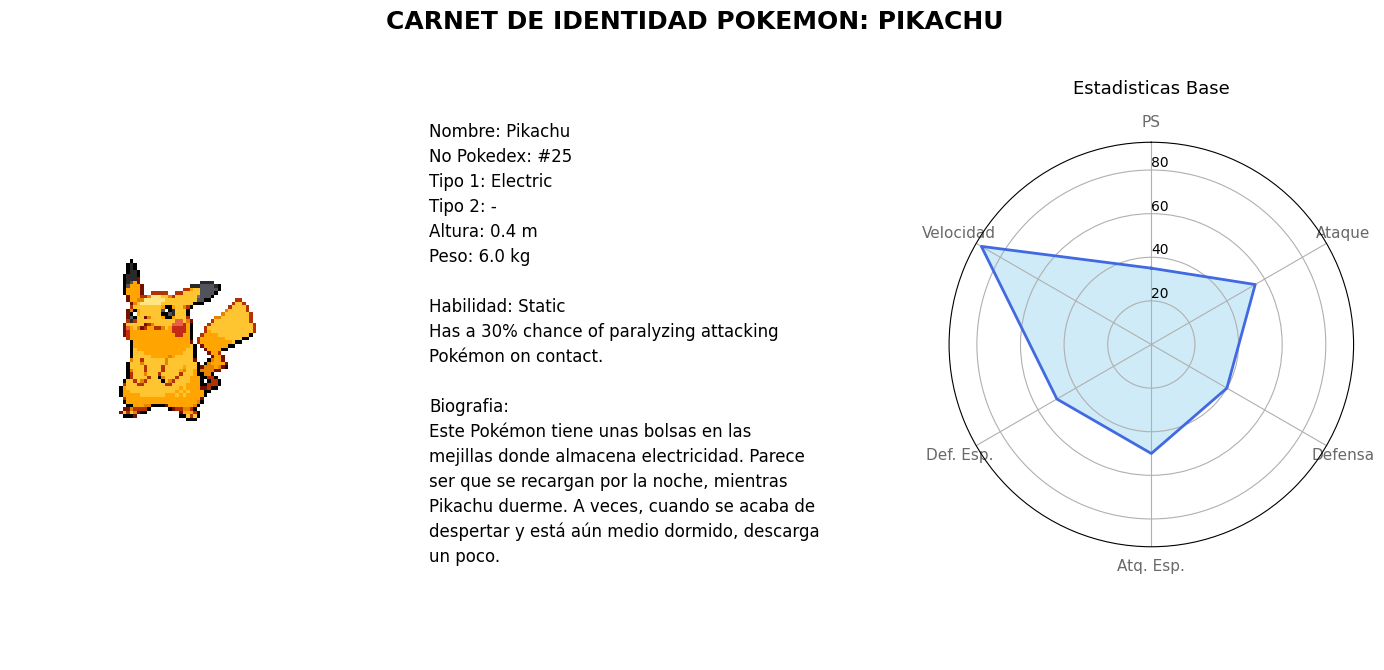

In [36]:
#Rellena los campos con la información de tu Dataframe y ejecuta!
crear_carnet(
    nombre= df_pika['nombre'][0], #El nombre de tu pokemon
    pokedex_id= df_pika['id'][0], #Id del pokemon
    tipo_1= df_pika['tipo_1'][0], #Tipo 1 del pokemon
    tipo_2= df_pika['tipo_2'][0], #el tipo 2
    altura= df_pika['altura'][0], #La altura del pokemon    
    peso= df_pika['peso'][0], #Su peso
    imagen= df_pika['img'][0], #Su imagen
    lista_stats=  (
        df_pika['hp'][0],
        df_pika['attack'][0],
        df_pika['defense'][0],
        df_pika['special-attack'][0],
        df_pika['special-defense'][0],
        df_pika['speed'][0]
    ), #Sus stats
    habilidad_nombre= df_pika['habilidad'][0], #EL nombre de su habilidad
    habilidad_efecto= df_pika['hab_desc'][0], #La descripción del efecto
    descripcion= df_pika['descripcion'][0] #La descripción de la especie del pokemon
);

### Paso 7 - Creando la base de datos de Kanto

Hasta ahora has procesado Carnets de Identidad uno a uno. Pero el Registro Civil necesita digitalizar a los 151 Pokémon originales de la región de Kanto de una sola vez.

Sabes como hacer requests a la API, ahora en vez de traerte los datos de un pokemon tienes que conseguir los de 151.

Además, tienes una función para procesar los datos en bruto del json de un pokemon, asi que utilízala para convertir esos 151 json en un dataframe nuevo hecho y derecho con los 151 pokemon de kanto.

In [19]:
pokedex = []

for n in range(1, 152):
    
    url = f"https://pokeapi.co/api/v2/pokemon/{n}"
    datos = requests.get(url)
    datos_json = datos.json()
    pokemon_datos = procesar_pokemon(datos_json)
    pokedex.append(pokemon_datos)
    
    print(f"Procesado: {pokemon_datos['nombre']} ({n}/152)")
    
df_poke = pd.DataFrame(pokedex)
df_poke


Procesado: bulbasaur (1/152)
Procesado: ivysaur (2/152)
Procesado: venusaur (3/152)
Procesado: charmander (4/152)
Procesado: charmeleon (5/152)
Procesado: charizard (6/152)
Procesado: squirtle (7/152)
Procesado: wartortle (8/152)
Procesado: blastoise (9/152)
Procesado: caterpie (10/152)
Procesado: metapod (11/152)
Procesado: butterfree (12/152)
Procesado: weedle (13/152)
Procesado: kakuna (14/152)
Procesado: beedrill (15/152)
Procesado: pidgey (16/152)
Procesado: pidgeotto (17/152)
Procesado: pidgeot (18/152)
Procesado: rattata (19/152)
Procesado: raticate (20/152)
Procesado: spearow (21/152)
Procesado: fearow (22/152)
Procesado: ekans (23/152)
Procesado: arbok (24/152)
Procesado: pikachu (25/152)
Procesado: raichu (26/152)
Procesado: sandshrew (27/152)
Procesado: sandslash (28/152)
Procesado: nidoran-f (29/152)
Procesado: nidorina (30/152)
Procesado: nidoqueen (31/152)
Procesado: nidoran-m (32/152)
Procesado: nidorino (33/152)
Procesado: nidoking (34/152)
Procesado: clefairy (35/152)


,id,nombre,habilidad,hab_desc,peso,altura,tipo_1,tipo_2,img,descripcion,hp,attack,defense,special-attack,special-defense,speed
0,1,bulbasaur,overgrow,Strengthens grass moves to inflict 1.5× damage...,69,7,grass,poison,https://raw.githubusercontent.com/PokeAPI/spri...,Puede sobrevivir largo tiempo sin probar\nboca...,45,49,49,65,65,45
1,2,ivysaur,overgrow,Strengthens grass moves to inflict 1.5× damage...,130,10,grass,poison,https://raw.githubusercontent.com/PokeAPI/spri...,La luz del sol lo fortalece y hace que le crez...,60,62,63,80,80,60
2,3,venusaur,overgrow,Strengthens grass moves to inflict 1.5× damage...,1000,20,grass,poison,https://raw.githubusercontent.com/PokeAPI/spri...,"Venusaur tiene una flor enorme en el lomo que,...",80,82,83,100,100,80
3,4,charmander,blaze,Strengthens fire moves to inflict 1.5× damage ...,85,6,fire,,https://raw.githubusercontent.com/PokeAPI/spri...,Este Pokémon nace con una llama en la punta de...,39,52,43,60,50,65
4,5,charmeleon,blaze,Strengthens fire moves to inflict 1.5× damage ...,190,11,fire,,https://raw.githubusercontent.com/PokeAPI/spri...,Charmeleon no tiene reparo en acabar con su ri...,58,64,58,80,65,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,147,dratini,shed-skin,Has a 33% chance of curing any major status ai...,33,18,dragon,,https://raw.githubusercontent.com/PokeAPI/spri...,Dratini muda y se despoja de la vieja piel con...,41,64,45,50,50,50
147,148,dragonair,shed-skin,Has a 33% chance of curing any major status ai...,165,40,dragon,,https://raw.githubusercontent.com/PokeAPI/spri...,Ha sido venerado desde tiempos ancestrales\npo...,61,84,65,70,70,70
148,149,dragonite,inner-focus,Prevents flinching.,2100,22,dragon,flying,https://raw.githubusercontent.com/PokeAPI/spri...,"Es bastante pacífico por naturaleza, pero, si\...",91,134,95,100,100,80
149,150,mewtwo,pressure,Increases the PP cost of moves targetting the ...,1220,20,psychic,,https://raw.githubusercontent.com/PokeAPI/spri...,Su ADN es casi el mismo que el de Mew.\nSin em...,106,110,90,154,90,130


### Paso 8 - EL último, ya acaba esto.

Ahora que tienes tu DataFrame con todos los pokemon de Kanto. Escoge uno aleatorio y hazle un CIP con la función de antes. Copia la imagen o guárdala para subirla a Slack y todos puedan ver a qué pokémon le has hecho el CIP!

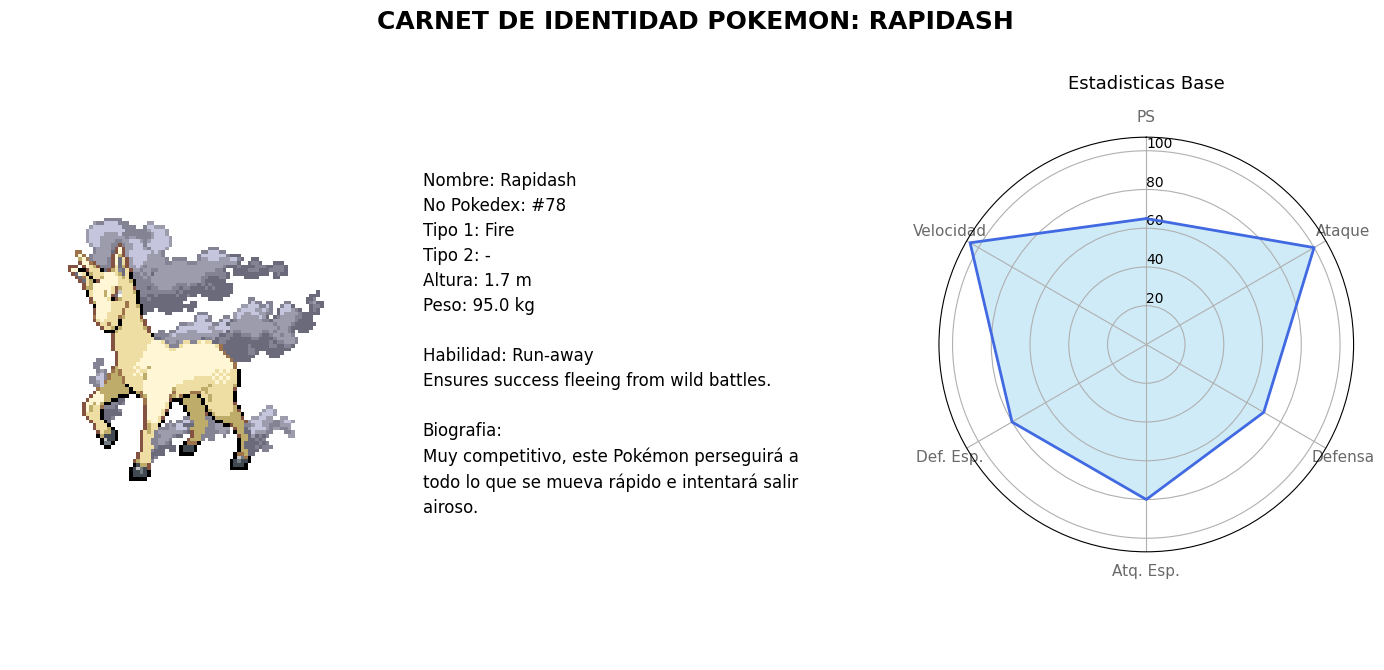

In [48]:
poke = df_poke.sample().iloc[0]

crear_carnet(
    nombre= poke['nombre'], #El nombre de tu pokemon
    pokedex_id= poke['id'], #Id del pokemon
    tipo_1= poke['tipo_1'], #Tipo 1 del pokemon
    tipo_2= poke['tipo_2'], #el tipo 2
    altura= poke['altura'], #La altura del pokemon    
    peso= poke['peso'], #Su peso
    imagen= poke['img'], #Su imagen
    lista_stats=  (
        poke['hp'],
        poke['attack'],
        poke['defense'],
        poke['special-attack'],
        poke['special-defense'],
        poke['speed']
    ), #Sus stats
    habilidad_nombre= poke['habilidad'], #EL nombre de su habilidad
    habilidad_efecto= poke['hab_desc'], #La descripción del efecto
    descripcion= poke['descripcion'] #La descripción de la especie del pokemon
);